# CIFAR-10 ResNet18

In [1]:
import os 
import numpy as np
import pandas as pd
from plt_rcs import *
import torch

In [3]:
plt.rc(group='figure', figsize=(4, 4))

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

In [4]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/dl'

In [5]:
os.chdir('../../data')

In [6]:
[i for i in os.listdir() if i.endswith('.pkl')]

['Diabetes.pkl',
 'Facility_Sensor_Raw.pkl',
 'Used_Cars_Prep.pkl',
 'Facility_Sensor_Out.pkl',
 'Used_Cars.pkl',
 'Encar_Merged_Prep_20220711.pkl',
 'WhiteWine.pkl',
 'Cereal.pkl',
 'Bank_Customer.pkl',
 'Marine_Product.pkl',
 'MNIST_Dataset.pkl',
 'APT_Price.pkl',
 'CIFAR10_Dataset.pkl']

In [7]:
from torchvision.datasets import CIFAR10
from torchvision import transforms

In [8]:
imagenet_avg = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

In [9]:
transform_train = transforms.Compose(
    transforms=[
        transforms.Resize(size=(128, 128)),
        transforms.RandomCrop(size=128, padding=8),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_avg, std=imagenet_std),
    ]
)

In [10]:
transform_test = transforms.Compose(
    transforms=[
        transforms.Resize(size=(128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_avg, std=imagenet_std),
    ]
)

In [12]:
train_cifar10 = CIFAR10(root='../data', train=True, transform=transform_train)
test_cifar10 = CIFAR10(root='../data', train=False, transform=transform_test)

In [13]:
train_cifar10_target = torch.tensor(data=train_cifar10.targets, dtype=torch.long)

In [15]:
n_per_class = 1000

In [16]:
sampled_indices = []
for class_id in range(10):
    class_indices = torch.where(train_cifar10_target == class_id)[0]
    shuffled_indices = class_indices[torch.randperm(n=len(class_indices))]
    selected_indices = shuffled_indices[:n_per_class]
    sampled_indices.append(selected_indices)

In [17]:
len(sampled_indices)

10

In [18]:
sampled_indices = torch.cat(tensors=sampled_indices, dim=0)

In [19]:
len(sampled_indices)

10000

In [20]:
sampled_indices = sampled_indices[torch.randperm(n=len(sampled_indices))]

In [21]:
from torch.utils.data import Subset

In [22]:
train_subset = Subset(dataset=train_cifar10, indices=sampled_indices.tolist())

In [23]:
from torch.utils.data import DataLoader

In [25]:
bs = 256

In [26]:
train_loader = DataLoader(dataset=train_subset, batch_size=bs, shuffle=True)
test_loader = DataLoader(dataset=test_cifar10, batch_size=bs, shuffle=False)

In [28]:
from torchvision import models

In [29]:
model = models.resnet18(weights=None)

In [30]:
import torch.nn as nn

In [32]:
model.fc = nn.Linear(in_features=model.fc.in_features, out_features=10)

In [33]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/data'

In [36]:
[i for i in os.listdir() if i.endswith('.pth')][0]

'CIFAR10_ResNet18.pth'

In [37]:
model_params = torch.load(f='CIFAR10_ResNet18.pth', map_location=torch.device('cpu'))

In [38]:
model.load_state_dict(model_params)

<All keys matched successfully>

In [39]:
os.chdir('../code/dl')

In [40]:
from trainer import Trainer, set_seed

In [41]:
set_seed(0)

In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.fc.parameters(), lr=0.001)

In [46]:
trainer = Trainer(
    model=model.to(device),
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=test_loader,
    flatten=False
)

[Trainer] Using device: mps:0


In [47]:
y_prob, y_pred, y_true = trainer.predict_loader(test_loader)

In [48]:
mis_index = torch.where(y_pred.ne(y_true))[0]

In [49]:
mis_index[:10]

tensor([22, 24, 25, 26, 37, 46, 47, 57, 58, 59])

In [50]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [51]:
target_layer = model.layer3[-1]

In [52]:
from gradcamviz import GradCAMViz

In [53]:
viewer = GradCAMViz(
    model=model,
    target_layer=target_layer,
    data_loader=test_loader
)

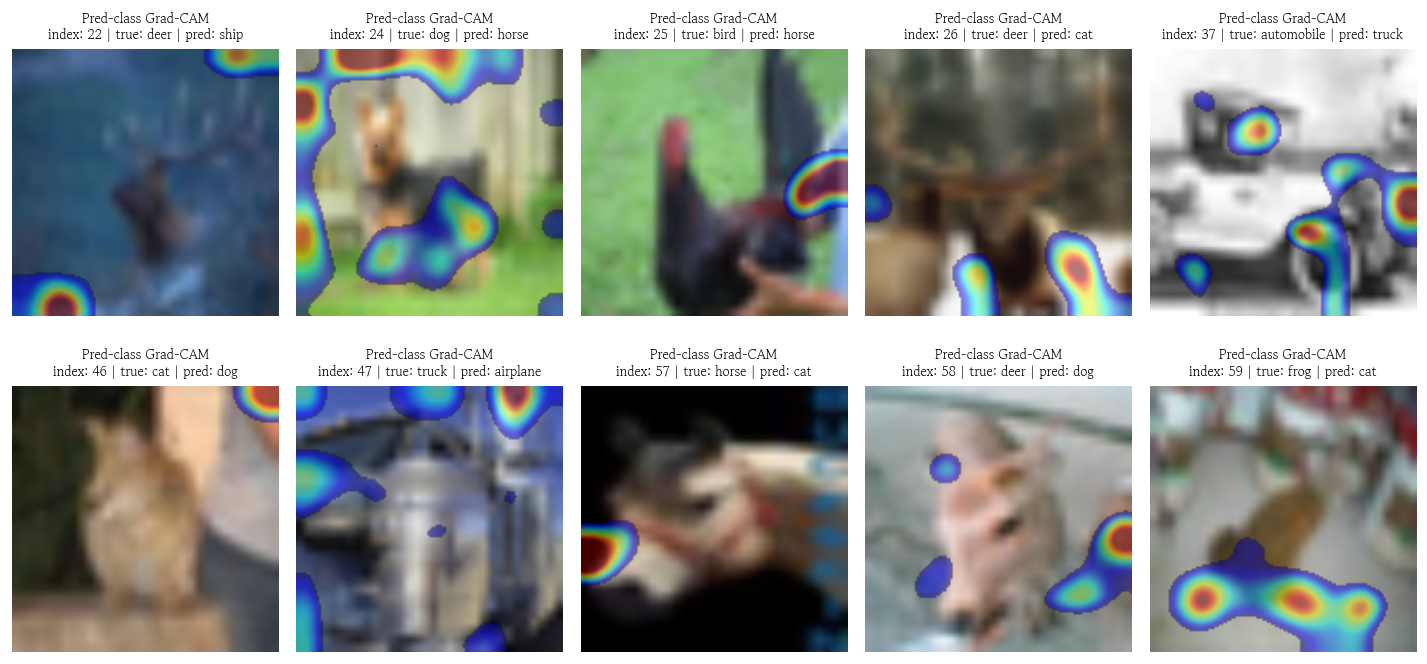

In [56]:
viewer.plot_multiple_samples(indices=mis_index[:10], nrows=2, ncols=5, mean=imagenet_avg, std=imagenet_std, style='enhanced');